# Exam 2

Author: Garrett Brown

Special Thanks: Joseph Madigan, Ethan Nelson, Cesar Garcia, Grace Napolitan, Kenzo Yui
# ———————————–

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

# This stops a few warning messages from showing
pd.options.mode.chained_assignment = None 
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
file_name = 'flights'
file_location = 'https://joannabieri.com/introdatascience/data/'+file_name+'.csv'
DF_flights = pd.read_csv(file_location)
file_name = 'weather'
file_location = 'https://joannabieri.com/introdatascience/data/'+file_name+'.csv'
DF_weather = pd.read_csv(file_location)
file_name = 'planes'
file_location = 'https://joannabieri.com/introdatascience/data/'+file_name+'.csv'
DF_planes = pd.read_csv(file_location)
file_name = 'airports'
file_location = 'https://joannabieri.com/introdatascience/data/'+file_name+'.csv'
DF_airports = pd.read_csv(file_location)
file_name = 'airlines'
file_location = 'https://joannabieri.com/introdatascience/data/'+file_name+'.csv'
DF_airlines = pd.read_csv(file_location)
DF_flights

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400.0,5.0,15.0,2013-01-01 10:00:00
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416.0,5.0,29.0,2013-01-01 10:00:00
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089.0,5.0,40.0,2013-01-01 10:00:00
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576.0,5.0,45.0,2013-01-01 10:00:00
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762.0,6.0,0.0,2013-01-01 11:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,NaN,1455,NaN,NaN,1634,NaN,9E,3393,NaN,JFK,DCA,NaN,213.0,14.0,55.0,2013-09-30 18:00:00
336772,2013,9,30,NaN,2200,NaN,NaN,2312,NaN,9E,3525,NaN,LGA,SYR,NaN,198.0,22.0,0.0,2013-10-01 02:00:00
336773,2013,9,30,NaN,1210,NaN,NaN,1330,NaN,MQ,3461,N535MQ,LGA,BNA,NaN,764.0,12.0,10.0,2013-09-30 16:00:00
336774,2013,9,30,NaN,1159,NaN,NaN,1344,NaN,MQ,3572,N511MQ,LGA,CLE,NaN,419.0,11.0,59.0,2013-09-30 15:00:00


In [22]:
DF_flights.describe()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,flight,air_time,distance,hour,minute
count,336776.0,336776.000000,336776.000000,328521.000000,336776.000000,328521.000000,328063.000000,336776.000000,327346.000000,336776.000000,327346.000000,336776.000000,336776.000000,336776.000000
mean,2013.0,6.548510,15.710787,1349.109947,1344.254840,12.639070,1502.054999,1536.380220,6.895377,1971.923620,150.686460,1039.912604,13.180247,26.230100
std,0.0,3.414457,8.768607,488.281791,467.335756,40.210061,533.264132,497.457142,44.633292,1632.471938,93.688305,733.233033,4.661316,19.300846
min,2013.0,1.000000,1.000000,1.000000,106.000000,-43.000000,1.000000,1.000000,-86.000000,1.000000,20.000000,17.000000,1.000000,0.000000
25%,2013.0,4.000000,8.000000,907.000000,906.000000,-5.000000,1104.000000,1124.000000,-17.000000,553.000000,82.000000,502.000000,9.000000,8.000000
50%,2013.0,7.000000,16.000000,1401.000000,1359.000000,-2.000000,1535.000000,1556.000000,-5.000000,1496.000000,129.000000,872.000000,13.000000,29.000000
75%,2013.0,10.000000,23.000000,1744.000000,1729.000000,11.000000,1940.000000,1945.000000,14.000000,3465.000000,192.000000,1389.000000,17.000000,44.000000
max,2013.0,12.000000,31.000000,2400.000000,2359.000000,1301.000000,2400.000000,2359.000000,1272.000000,8500.000000,695.000000,4983.000000,23.000000,59.000000


# P. Preliminaries(5 points)
Do an initial exploration of the flights data. Report on all the typical things: Variables, Observations, Data Types, Weirdness or NaNs…

There are 19 variables and 336776 observations in the data set. There are 14 numeric variables and 5 string variables, although one of the string variables is a few numeric variables being appended together. Some data is missing for some flights.

# 1. Question 1 (5 points)
What are the ten most common destinations for flights from NYC airports in 2013?

Make a table (Data Frame) that lists these in descending order of frequency and shows the number of flights heading to each airport.

In [53]:
DF_destinations = pd.DataFrame(DF_flights[['dest']].value_counts())
show(DF_destinations)

Loading ITables v2.5.2 from the internet... (need help?)


The ten most common destinations for flights departing from NYC are ORD, ATL, LAX, BOS, MCO, CLT, SFO, FLL, MIA, and DCA.

# 2. Question 2 (5 points)
Which airlines have the most flights departing from NYC airports in 2013?

Make a table(Data Frame) that lists these in descending order of frequency and shows the number of flights for each airline. In your narrative mention the names of the airlines as well.

In [23]:
DF_airlines

,carrier,name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.
5,EV,ExpressJet Airlines Inc.
6,F9,Frontier Airlines Inc.
7,FL,AirTran Airways Corporation
8,HA,Hawaiian Airlines Inc.
9,MQ,Envoy Air


In [45]:
DF_departing = pd.DataFrame(DF_flights[['carrier']].value_counts())
DF_departing

,count
carrier,
UA,58665
B6,54635
EV,54173
DL,48110
AA,32729
MQ,26397
US,20536
9E,18460
WN,12275


In [85]:
DF_newtable = pd.merge(DF_departing, DF_airlines, on='carrier')
DF_newtable

,carrier,count,name
0,UA,58665,United Air Lines Inc.
1,B6,54635,JetBlue Airways
2,EV,54173,ExpressJet Airlines Inc.
3,DL,48110,Delta Air Lines Inc.
4,AA,32729,American Airlines Inc.
5,MQ,26397,Envoy Air
6,US,20536,US Airways Inc.
7,9E,18460,Endeavor Air Inc.
8,WN,12275,Southwest Airlines Co.
9,VX,5162,Virgin America


The airlines with the most flights departing NYC in 2013 were United Air Lines Inc., JetBlue Airways, ExpressJet Airlines Inc., and Delta Air Lines Inc.

# 3. Question 3 (10 points)
Consider only flights that have non-missing arrival delay information and answer the questions below. Your answer should include the name of the carrier in addition to the carrier code and the values asked.

a. Which carrier had the highest mean arrival delay?

b. Which carrier had the lowest mean arrival delay?

In [78]:
DF_arrdelay = pd.DataFrame(DF_flights[['arr_delay', 'carrier']].dropna())
DF_arrdelay

,arr_delay,carrier
0,11.0,UA
1,20.0,UA
2,33.0,AA
3,-18.0,B6
4,-25.0,DL
...,...,...
336765,-17.0,B6
336766,-20.0,B6
336767,-16.0,B6
336768,1.0,B6


In [88]:
DF_delay = pd.DataFrame(DF_arrdelay.groupby(by=['carrier']).sum())

In [92]:
DF_newertable = DF_newtable.merge(DF_delay, on='carrier', how='left')

In [94]:
DF_newertable['meandelay'] = DF_newertable['arr_delay'] / DF_newertable['count']
DF_newertable.sort_values(by='meandelay', ascending=False)

,carrier,count,name,arr_delay,meandelay
12,F9,685,Frontier Airlines Inc.,14928.0,21.792701
10,FL,3260,AirTran Airways Corporation,63868.0,19.591411
2,EV,54173,ExpressJet Airlines Inc.,807324.0,14.902701
13,YV,601,Mesa Airlines Inc.,8463.0,14.081531
15,OO,32,SkyWest Airlines Inc.,346.0,10.812500
5,MQ,26397,Envoy Air,269767.0,10.219608
8,WN,12275,Southwest Airlines Co.,116214.0,9.467536
1,B6,54635,JetBlue Airways,511194.0,9.356530
7,9E,18460,Endeavor Air Inc.,127624.0,6.913543
0,UA,58665,United Air Lines Inc.,205589.0,3.504458


The carrier with the largest mean arrival delay of flights that departed from NYC in 2013 was Frontier Airlines Inc., while the carrier with the smalles mean arrival delay of flights that departed from NYC in 2013 was Alaska Airlines Inc.

# 4. Question 4 (15 points)
Consider breaking the day into four time intervals: 12:00am-6am, 6:01am-12pm, 12:01pm-6pm, 6:01pm-11:59pm, then answer the questions below.

a. Calculate the proportion of flights that are delayed at departure at each of these time intervals.

b. Comment on how the likelihood of being delayed change throughout the day? What is the probability of being delayed given each time period?

In [4]:
DF_depdelay = pd.DataFrame(DF_flights[['dep_delay', 'sched_dep_time']].dropna())
DF_depdelay

,dep_delay,sched_dep_time
0,2.0,515
1,4.0,529
2,2.0,540
3,-1.0,545
4,-6.0,600
...,...,...
336765,-5.0,2245
336766,-10.0,2250
336767,-5.0,2246
336768,12.0,2255


In [7]:
DF_depdelay['dep_time_period'] = DF_depdelay['sched_dep_time'].apply(lambda x: 'night' if x <= 601 else 'morning' if x <= 1200 else 'afternoon' if x <= 1800 else 'evening')
DF_depdelay

,dep_delay,sched_dep_time,is_delayed,dep_time_period
0,2.0,515,ontime,night
1,4.0,529,ontime,night
2,2.0,540,ontime,night
3,-1.0,545,delayed,night
4,-6.0,600,delayed,night
...,...,...,...,...
336765,-5.0,2245,delayed,evening
336766,-10.0,2250,delayed,evening
336767,-5.0,2246,delayed,evening
336768,12.0,2255,ontime,evening


In [8]:
DF_depdelay['is_delayed'] = DF_depdelay['dep_delay'].apply(lambda x: 'delayed' if x<=0 else 'ontime')
DF_depdelay

,dep_delay,sched_dep_time,is_delayed,dep_time_period
0,2.0,515,ontime,night
1,4.0,529,ontime,night
2,2.0,540,ontime,night
3,-1.0,545,delayed,night
4,-6.0,600,delayed,night
...,...,...,...,...
336765,-5.0,2245,delayed,evening
336766,-10.0,2250,delayed,evening
336767,-5.0,2246,delayed,evening
336768,12.0,2255,ontime,evening


In [18]:
DF_numdelays = pd.DataFrame(DF_depdelay[['dep_time_period', 'is_delayed']].value_counts()).sort_values(by='count', ascending=False)
DF_numdelays

count
dep_time_period is_delayed       
morning         delayed     92040
afternoon       delayed     67773
                ontime      58325
evening         ontime      35822
                delayed     33126
morning         ontime      32410
night           delayed      7150
                ontime       1875

In [16]:
DF_numdelays['total'] = DF_depdelay[['dep_time_period']].value_counts()
DF_numdelays

count   total
dep_time_period is_delayed               
morning         delayed     92040  124450
afternoon       delayed     67773  126098
                ontime      58325  126098
evening         ontime      35822   68948
                delayed     33126   68948
morning         ontime      32410  124450
night           delayed      7150    9025
                ontime       1875    9025

In [134]:
DF_numdelays['percentage'] = DF_numdelays['count'] / DF_numdelays['total']
DF_numdelays

count   total  percentage
dep_time_period is_delayed                           
afternoon       False       67773  126098    0.537463
                True        58325  126098    0.462537
evening         True        35822   68948    0.519551
                False       33126   68948    0.480449
morning         False       92040  124450    0.739574
                True        32410  124450    0.260426
night           False        7150    9025    0.792244
                True         1875    9025    0.207756

At night and in the morning, you were much less likely to be delayed, but as the time of day progresses, the likelyhood of a delay increases.

It goes: \
Night (12:00am-6:00am) - 20.78% chance of delay \
Morning (6:01am-12:00pm) - 26.04% chance of delay \
Afternoon (12:01pm-6:00pm) - 46.25% chance of delay \
Evening (6:01pm-11:59pm) - 51.96% chance of delay

# 5. Question 5 (15 points)
Find the flight with the longest air time.

a. How long is this flight?

b. What city did it fly to?

c. How many seats does the plane that flew this flight have?

In [144]:
DF_flights.sort_values(by='air_time', ascending=False)

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
151467,2013,3,17,1337.0,1335,2.0,1937.0,1836,61.0,UA,15,N77066,EWR,HNL,695.0,4963.0,13.0,35.0,2013-03-17 17:00:00
115752,2013,2,6,853.0,900,-7.0,1542.0,1540,2.0,HA,51,N389HA,JFK,HNL,691.0,4983.0,9.0,0.0,2013-02-06 14:00:00
149618,2013,3,15,1001.0,1000,1.0,1551.0,1530,21.0,HA,51,N388HA,JFK,HNL,686.0,4983.0,10.0,0.0,2013-03-15 14:00:00
151311,2013,3,17,1006.0,1000,6.0,1607.0,1530,37.0,HA,51,N380HA,JFK,HNL,686.0,4983.0,10.0,0.0,2013-03-17 14:00:00
150547,2013,3,16,1001.0,1000,1.0,1544.0,1530,14.0,HA,51,N384HA,JFK,HNL,683.0,4983.0,10.0,0.0,2013-03-16 14:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,NaN,1455,NaN,NaN,1634,NaN,9E,3393,NaN,JFK,DCA,NaN,213.0,14.0,55.0,2013-09-30 18:00:00
336772,2013,9,30,NaN,2200,NaN,NaN,2312,NaN,9E,3525,NaN,LGA,SYR,NaN,198.0,22.0,0.0,2013-10-01 02:00:00
336773,2013,9,30,NaN,1210,NaN,NaN,1330,NaN,MQ,3461,N535MQ,LGA,BNA,NaN,764.0,12.0,10.0,2013-09-30 16:00:00
336774,2013,9,30,NaN,1159,NaN,NaN,1344,NaN,MQ,3572,N511MQ,LGA,CLE,NaN,419.0,11.0,59.0,2013-09-30 15:00:00


In [145]:
DF_planes[DF_planes['tailnum']=='N77066']

,tailnum,year,type,manufacturer,model,engines,seats,speed,engine
2444,N77066,2002.0,Fixed wing multi engine,BOEING,767-424ER,2,292,NaN,Turbo-jet


The flight that was in the air the longest was in the air for 11 hours and 35 minutes and flew 4963 miles from EWR to HNL. The airplane was a Boeing 767-424ER, which has 292 seats, although the plane may have been modified by the airline to save fuel, potentially to make the aircraft eligible to fly the route in the first place.

# 6. Question 6 (15 pts)
The airports data frame contains information on a large number of primarily American airports. These data include location information for these airports in the form of latitude and longitude coordinates. In this question we limit our focus to the Contiguous United States. Visualize and describe the distribution of the longitudes of airports in the Contiguous United States. What does this tell you about the geographical distribution of these airports?

In [191]:
# I didn't like that going off of purely longitude and latitude made a rectangle which left room for Canadian and Mexican airports to sneak into the data, 
# so I found my own data set of US Airports

DF_us_airports = pd.read_csv('us-airports.csv')

DF_us_airports

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,country_name,iso_country,...,scheduled_service,gps_code,icao_code,iata_code,local_code,home_link,wikipedia_link,keywords,score,last_updated
0,3632,KLAX,large_airport,Los Angeles International Airport,33.942501,-118.407997,125.0,NaN,United States,US,...,1,KLAX,KLAX,LAX,LAX,https://www.flylax.com/,https://en.wikipedia.org/wiki/Los_Angeles_Inte...,Tom Bradley,1335475,2024-04-02T16:36:13+00:00
1,3754,KORD,large_airport,Chicago O'Hare International Airport,41.978600,-87.904800,680.0,NaN,United States,US,...,1,KORD,KORD,ORD,ORD,https://www.flychicago.com/ohare/home/pages/de...,https://en.wikipedia.org/wiki/O'Hare_Internati...,"CHI, Orchard Place",1503175,2024-03-09T23:28:49+00:00
2,3622,KJFK,large_airport,John F Kennedy International Airport,40.639447,-73.779317,13.0,NaN,United States,US,...,1,KJFK,KJFK,JFK,JFK,https://www.jfkairport.com/,https://en.wikipedia.org/wiki/John_F._Kennedy_...,"Manhattan, New York City, NYC, Idlewild, IDL, ...",1052075,2022-10-18T18:49:55+00:00
3,3384,KATL,large_airport,Hartsfield Jackson Atlanta International Airport,33.636700,-84.428101,1026.0,NaN,United States,US,...,1,KATL,KATL,ATL,ATL,https://www.atl.com,https://en.wikipedia.org/wiki/Hartsfield–Jacks...,NaN,2002475,2025-09-12T16:52:18+00:00
4,3878,KSFO,large_airport,San Francisco International Airport,37.619806,-122.374821,13.0,NaN,United States,US,...,1,KSFO,KSFO,SFO,SFO,http://www.flysfo.com/,https://en.wikipedia.org/wiki/San_Francisco_In...,"QSF, QBA",1112475,2024-04-02T16:43:50+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32210,342483,US-3397,closed,Lake Mountain Landing Strip,40.021280,-123.403670,3392.0,NaN,United States,US,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2021-03-30T13:04:34+00:00
32211,322813,US-0527,heliport,AdventHealth Zephyrhills Heliport,28.261934,-82.185663,160.0,NaN,United States,US,...,0,FD75,NaN,NaN,FD75,NaN,NaN,Florida Hospital Zephyrhills Heliport,0,2021-06-11T17:55:06+00:00
32212,324916,US-0652,heliport,Rotary Run Heliport,40.605805,-81.415002,1027.0,NaN,United States,US,...,0,NaN,NaN,NaN,0OH2,NaN,NaN,NaN,0,2017-09-09T20:04:27+00:00
32213,327838,US-0874,heliport,Black Rock Heliport,35.084975,-108.788350,6454.0,NaN,United States,US,...,0,NaN,NaN,NaN,NM1,NaN,NaN,NaN,0,2018-05-15T23:12:01+00:00


In [165]:
DF_coded_us_airports = pd.DataFrame(DF_us_airports[['region_name', 'local_code']].dropna())
DF_coded_us_airports

,region_name,local_code
0,California,LAX
1,Illinois,ORD
2,New York,JFK
3,Georgia,ATL
4,California,SFO
...,...,...
32204,Louisiana,3LA5
32207,Michigan,MI51
32211,Florida,FD75
32212,Ohio,0OH2


In [166]:
DF_american_airports = DF_airports.merge(DF_coded_us_airports, how='inner', left_on='faa', right_on='local_code')
show(DF_american_airports)

Loading ITables v2.5.2 from the internet... (need help?)


In [188]:
# Cleaning Data
DF_no_alaska = DF_american_airports[DF_american_airports['region_name']!='Alaska']
DF_no_alaska_hawaii = DF_no_alaska[DF_no_alaska['region_name']!='Hawaii']
DF_no_east = DF_no_alaska_hawaii[DF_no_alaska_hawaii['lon'] < 0]
DF_contiguous = DF_no_east[DF_no_alaska_hawaii['lon'] > -150]
show(DF_contiguous)

C:\Users\garrr\AppData\Local\Temp\ipykernel_3096\3965600843.py:5: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



Loading ITables v2.5.2 from the internet... (need help?)


In [181]:
DF_contiguous['region_name'].nunique()

49

In [182]:
DF_contiguous['region_name'].drop_duplicates()

0                      Ohio
1                   Alabama
2                  Illinois
3                  New York
4                   Georgia
5                 Tennessee
8              Pennsylvania
9                Washington
10                 Maryland
14            Massachusetts
15               California
17                  Arizona
20              Mississippi
21                 Michigan
22                  Florida
23                Minnesota
32                Wisconsin
35           South Carolina
42              Connecticut
45                  Montana
51           North Carolina
56                   Oregon
61               New Jersey
69                    Texas
70               New Mexico
71             South Dakota
79                 Oklahoma
83                Louisiana
90                 Nebraska
92                 Missouri
101                    Iowa
102                Colorado
113                 Indiana
128           New Hampshire
134                   Maine
147                 

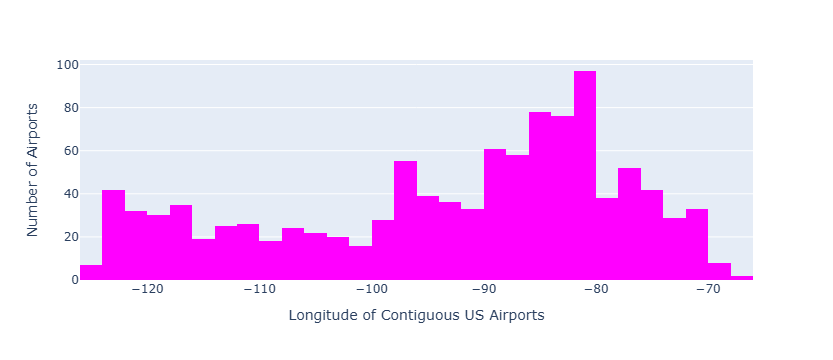

In [187]:
longitude_graph = px.histogram(DF_contiguous,
                                x='lon',
                                color_discrete_sequence=['magenta']
                             )
longitude_graph.update_layout(
                                title_x=0.5,
                                xaxis_title='Longitude of Contiguous US Airports',
                                yaxis_title='Number of Airports'
)
longitude_graph.show()

Most airports tend to be on the Eastern side of the Contiguous United States, although there is a big clump around the "midwestern" US. 

# 7. Question 7 (15 pts)
Recreate the plot included below using the flights data. Do the best you can to get as close as possible to what you see here. Once you have created the visualization, in no more than one paragraph, describe what you think the point of this visualization might be.

In [23]:
DF_flights['arrival'] = DF_flights['arr_delay'].apply(lambda x: 'ontime' if x<=0 else 'delayed')
DF_flights

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,arrival
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400.0,5.0,15.0,2013-01-01 10:00:00,delayed
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416.0,5.0,29.0,2013-01-01 10:00:00,delayed
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089.0,5.0,40.0,2013-01-01 10:00:00,delayed
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576.0,5.0,45.0,2013-01-01 10:00:00,ontime
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762.0,6.0,0.0,2013-01-01 11:00:00,ontime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,NaN,1455,NaN,NaN,1634,NaN,9E,3393,NaN,JFK,DCA,NaN,213.0,14.0,55.0,2013-09-30 18:00:00,delayed
336772,2013,9,30,NaN,2200,NaN,NaN,2312,NaN,9E,3525,NaN,LGA,SYR,NaN,198.0,22.0,0.0,2013-10-01 02:00:00,delayed
336773,2013,9,30,NaN,1210,NaN,NaN,1330,NaN,MQ,3461,N535MQ,LGA,BNA,NaN,764.0,12.0,10.0,2013-09-30 16:00:00,delayed
336774,2013,9,30,NaN,1159,NaN,NaN,1344,NaN,MQ,3572,N511MQ,LGA,CLE,NaN,419.0,11.0,59.0,2013-09-30 15:00:00,delayed


In [24]:
DF_eligible_flights = pd.DataFrame(DF_flights[['dep_delay', 'origin', 'dest', 'arrival', 'month']].dropna())
show(DF_eligible_flights)

Loading ITables v2.5.2 from the internet... (need help?)


In [25]:
DF_december_flights = pd.DataFrame(DF_eligible_flights[DF_eligible_flights['month'] == 12])
show(DF_december_flights)

Loading ITables v2.5.2 from the internet... (need help?)


In [26]:
DF_valid_flights = pd.DataFrame(DF_december_flights[(DF_december_flights['dest']=='PHL') | (DF_december_flights['dest']=='RDU')]).sort_values(by='dest', ascending=True)
show(DF_valid_flights)

Loading ITables v2.5.2 from the internet... (need help?)


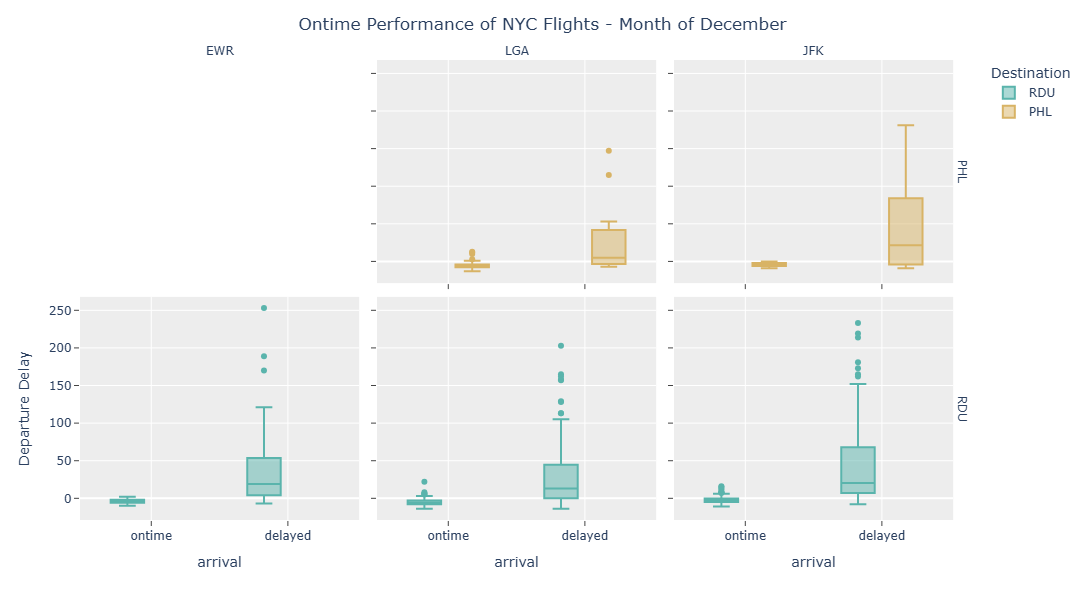

In [64]:
boxplot = px.box(DF_valid_flights,
                x='arrival',
                y='dep_delay',
                color='dest',
                facet_row='dest',
                facet_col='origin',
                width=900,
                height=600,
                color_discrete_sequence=['#D8B365', '#5AB4AC'], # i thought this was the Pastel color scheme at first lol
                category_orders={'origin': ['EWR', 'LGA', 'JFK'], 'dest': ['PHL', 'RDU'], 'arrival': ['ontime', 'delayed']})
boxplot.update_layout(
                    title='Ontime Performance of NYC Flights - Month of December',
                    title_x=0.5,
                    yaxis_title='Departure Delay',
                    legend_title='Destination',
                    plot_bgcolor='#EDEDED')
boxplot.update_xaxes(
                    showgrid=True,
                    ticks='outside')
boxplot.update_yaxes(
                    showgrid=True,
                    ticks='outside')
# NOTE: I FOUND THE TWO LINES OF CODE BELOW ON THE PLOTLY FORUMS. 
# I UNDERSTAND WHAT THEY ARE DOING BUT I AM UNSURE IF I AM ALLOWED TO USE THEM.
# I HAD TO CHANGE THEM A BIT TO DO WHAT I WANTED THEM TO DO.
# I FIGURED I'D INCLUDE THEM SINCE MOST OF PROGRAMMING IS OFTEN JUST 
# SEARCHING UP YOUR PROBLEMS AND FINDING A SNIPPET OF SOMEONE ELSE'S CODE TO CHANGE.
# PLEASE COMMENT THEM OUT IF YOU FEEL THIS WAS NOT ALLOWED.
# I DON'T KNOW WHY I'M WRITING IN ALL CAPS.
boxplot.for_each_annotation(lambda x: x.update(text=x.text.replace('origin=', '')))
boxplot.for_each_annotation(lambda x: x.update(text=x.text.replace('dest=', '')))
# END OF ADAPTED CODE
# THEY BASICALLY TAKE EACH ANNOTATION AND USE A LAMBDA TO SET IT EQUAL TO A VERSION OF ITSELF 
# WHERE IF IT HAD A TAG THAT TAG WAS CHANGED INTO NOTHING SO ITS AS IF IT WAS NEVER THERE
boxplot.show()

I think the point of this visualization is to highlight the differences in departure delay between flights that arrived on time and flights that didn't. It's common sense to assume the two go hand in hand, since the later you leave, the less likely you are to be on time, but the graph highlights that not all flights with delayed departures end up arriving later than their expected arrival times. It also highlights the differences between flight paths-- the paths from LGA seem to be more loose whereas the flight paths from EWR are roughly unchangeable.

# 8. Question 8 (15 pts)
Create your own data visualization that explores delayed flights. Here you are using any or all of the data sets to explore a question related to delayed flights.

Really show off here! I reserve the right to assign up to 5 points extra credit for really outstanding analysis, explanations, and multiple explorations here.

My graph aims to visualize the relationship between how delayed a flights is and its predicted air time.

In [67]:
DF_airtime = pd.DataFrame(DF_flights[['dep_delay', 'air_time', 'sched_dep_time', 'sched_arr_time']].dropna())
show(DF_airtime)

Loading ITables v2.5.2 from the internet... (need help?)


In [70]:
DF_airtime['sched_air_time'] = DF_airtime['sched_arr_time'] - DF_airtime['sched_dep_time']
DF_airtime['sched_air_time'] = DF_airtime['sched_air_time'].apply(lambda x: x if x>0 else x+2400) # accounting for time wraparound
show(DF_airtime)

Loading ITables v2.5.2 from the internet... (need help?)


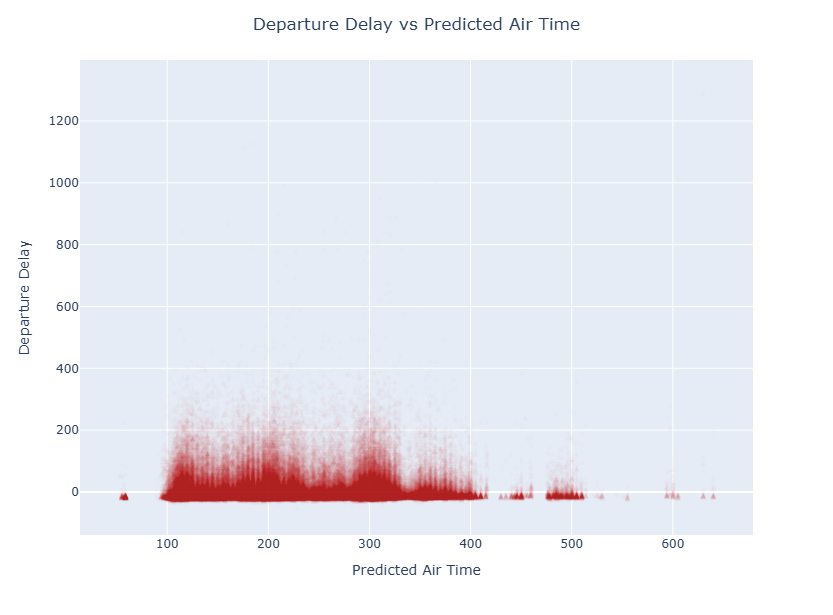

In [103]:
airtime = px.scatter(DF_airtime,
                     x='sched_air_time',
                     y='dep_delay',
                     opacity=0.015,
                     color_discrete_sequence=['firebrick'], # get it, like fire? this was supposed to be a heatmap but those arent in plotly express lol so this'll have to do
                     width=900,
                     height=600,
                    )
airtime.update_layout(
                     title='Departure Delay vs Predicted Air Time',
                     title_x=0.5,
                     xaxis_title='Predicted Air Time',
                     yaxis_title='Departure Delay'
                     )
airtime.update_traces(marker={'symbol': 'arrow-bar-up'})
airtime.show()

After looking at the graph, I can say that I have absolutely no idea whether there is a relationship or not. Maybe the average delay gets shorter the longer the flight is predicted to be? It's much more probable that the lack of large mounds of high delay data points is representative of the lack of data points for flights with a long predicted air time. Thus, my conclusion is that I cannot determine whether there is a correlation between the predicted air time of a flight and the departure delay of said flight. In any case, my goal with this graph was to emulate a heatmap with a scatter plot, and given that it literally looks like fire, I think I succeeded with that.